In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [3]:
words = open('names.txt', 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
len(words)

32033

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {c: i+1 for i, c in enumerate(chars)}
stoi['.'] = 0
itos = {i: c for c, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(stoi)

In [101]:
# build the datasets
block_size = 3
def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182441, 3]) torch.Size([182441])
torch.Size([22902, 3]) torch.Size([22902])
torch.Size([22803, 3]) torch.Size([22803])


In [ ]:
# MLP revisited

n_emb = 10 # the dim of the char embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.rand((vocab_size, n_emb), generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g)   * (5/3)/((n_emb * block_size)**0.5)
#b1 = torch.randn(n_hidden, generator=g)                         * 0.01 # can be left out because of bnbias
W2 = torch.randn((n_hidden, vocab_size), generator=g)           * 0.1
b2 = torch.randn(vocab_size, generator=g)                       * 0

bngain = torch.ones((1, n_hidden)) # batch normalization gain
bnbias = torch.zeros((1, n_hidden)) # batch normalization bias
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

# notice that bngain and bnbias are also trainable parameters
parameters = [C, W1, b1, W2, b2, bnbias, bngain]
print(sum(p.nelement() for p in parameters)) # num of params in total
for p in parameters:
    p.requires_grad = True

12297


In [ ]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # linear layer
    hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation , b1 can be left out when bnbias is used
    # batch norm layer
    # ------------------------------------------------------------------------------
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias# batch normalization

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    #-------------------------------------------------------------------------------
    # non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backwards pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update values
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    #break


      0/ 200000: 3.6348
  10000/ 200000: 2.1110
  20000/ 200000: 2.4557
  30000/ 200000: 2.7182
  40000/ 200000: 2.0550
  50000/ 200000: 1.9599
  60000/ 200000: 1.7645
  70000/ 200000: 2.2644
  80000/ 200000: 2.1080
  90000/ 200000: 2.3126
 100000/ 200000: 1.7430
 110000/ 200000: 2.0052
 120000/ 200000: 2.0695
 130000/ 200000: 2.0106
 140000/ 200000: 2.1743
 150000/ 200000: 2.2831
 160000/ 200000: 1.8975
 170000/ 200000: 1.7061
 180000/ 200000: 2.3627
 190000/ 200000: 1.8998


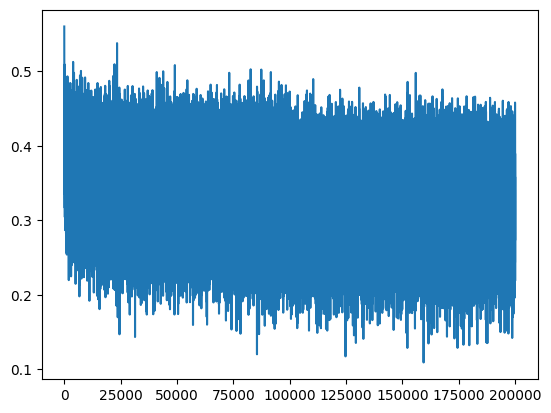

In [109]:
plt.plot(lossi)

In [118]:
# calibrate the batch norm at the end of training
# note, this is done as running average in the code, since no-one actually re-calculates 
# these after the training

with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # measure the mean and/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)


In [129]:
@torch.no_grad
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    emb = C[x] # (N, block_size, n_emb)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_emb)
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias# batch normalization
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact) # (N, hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0699610710144043
val 2.1179347038269043


In [ ]:
"""
the training values have progressivelu gone from ~2.15 to ~2.0 when the initialization have been
fixed from softmax being confidently wrong (too wide initialization values) and the tanh layer being
too saturated (too many values in extreme ends of the tanf function). Basically we are spending more
time training in the 'hard' zone.

But for a shallow layer like the current one, these are easy solutions. When there are more layers,
like 50 or more, these problems stack up and it's not as easy to find solutions to combat these
problems. 
"""

In [19]:
# sample from the model

for i in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])] # (1, block_size, n_emb)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.', break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out)) # decode and print the generated word
    

rmophli.
karro.
kosi.
sovessa.
korriolyndoyah.
zeya.
sirahil.
gondr.
rylondackenorasorge.
develleritpe.
leon.
norenoladeroha.
zhalat.
lesiya.
roko.
rez.
zaishley.
parrie.
nirie.
kyliana.


In [ ]:
"""
We should know about how big the loss should be, and at the start it should not be as high as 16.65.. but
much closer to the following values.

0/ 200000: 16.6505
10000/ 200000: 2.4505
20000/ 200000: 2.6029
30000/ 200000: 3.0173
...

At initialization we whould not expect any character to be more probable than some other, so the probability
distribution initially should be a uniform distribution assigning about equal probability to all the characters.
So we'd expect the probability for any character to be roughly 1 / 27 in this case. The loss then should be 
a negative log loss of the probability: -torch.tensor(1/27.0).log() ~= 3.29.
Right now the initialization is creating a probability distribution that is all messed up, some character are
very confident, and some are not confident at all. So the network is very confidently wrong. Below is an
example of what we should expect.

The loss we would expect is ~1.38

If you change values in the 4-dim example for the logits tensor, you can see what the randomly initialized
values do to the loss. torch.randn assigns values in very large values upon initialization, which is
exactly this issue.

to combat this you can multiply b2 * 0 and W2 * 0.1 or maybe 0.01 to get closer to the assumed loss value.

"""

'\nWe should know about how big the loss should be, and at the start it should not be as high as:\n'

In [ ]:
print(-torch.tensor(1/27.0).log())

# 4-dimensional example of the issue
logits = torch.tensor([0.0, 0.0, 0.0, 0.0]) # try changing values and you see how assigning too much probs
probs = torch.softmax(logits, dim=0)        # to some other value skewes the loss, e.g. [0, 5, 0, 0]
loss = -probs[2].log()
probs, loss

tensor(3.2958)


(tensor([0.2500, 0.2500, 0.2500, 0.2500]), tensor(1.3863))

In [ ]:
"""
Another proble is the hidden layer and the values it puts out. If you look at the tensor h, you can
see that there are alot of extreme values 1 and -1. 
"""

tensor([[ 1.0000],
        [-0.8365],
        [ 1.0000],
        [ 0.9999],
        [ 1.0000],
        [ 1.0000],
        [ 0.2568],
        [ 1.0000],
        [ 0.9995],
        [ 0.9999]], grad_fn=<SliceBackward0>)


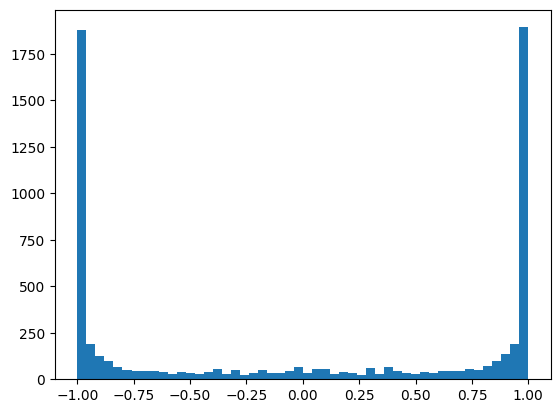

In [55]:
print(h[:10, :1])
# squash the h into one vector and plot to a histogram
plt.hist(h.view(-1).tolist(), bins=50);

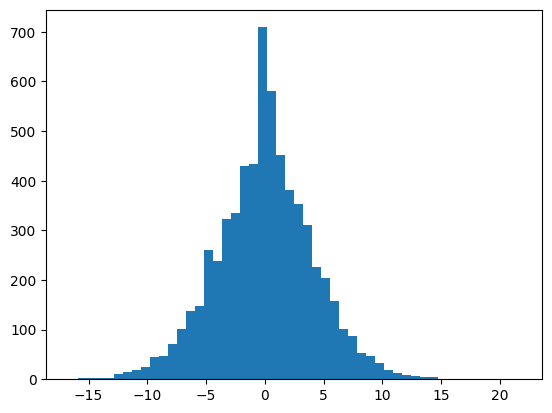

In [ ]:
# explanation to the above comes from hpreact, look what values it has:
plt.hist(hpreact.view(-1).tolist(), 50);
# values are roughly between -15 and 15

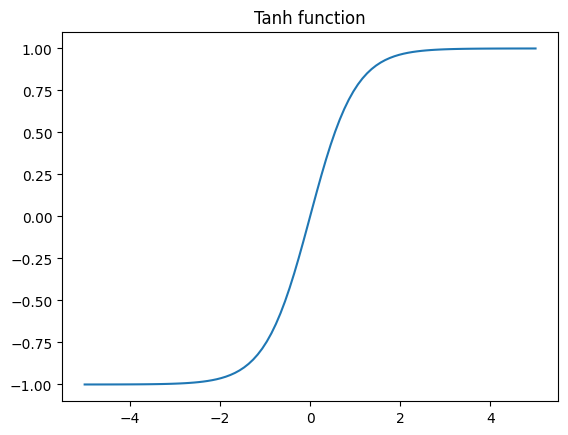

In [ ]:
"""
In a backpropagations backwards pass we derivate the tanh function backwards. Since tanh outputs values
between, 1 and -1, and the extreme values fall on the extreme ends, we essentially derivate as
(1 - t**2) * out.grad, in which t = -1 or 1, so we don't have any effect on the gradient in the backwards
pass because the gradient in the extreme ends is close to 0. So when the gradient is 0: 0 * out.grad
basically just zeroes the parameter value:

    # update parameters
    for p in parameters:
        p.data += -lr * p.grad <- p.grad is 0 or very close, so the data never changes

This is the vanishing gradient effect.
"""

plt.plot(torch.linspace(-5, 5, 100), torch.tanh(torch.linspace(-5, 5, 100)));
plt.title('Tanh function');


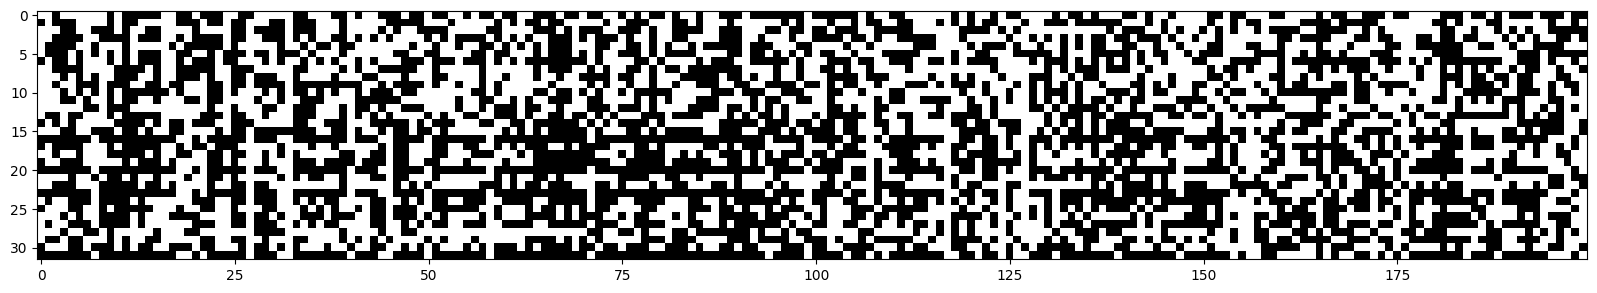

In [ ]:
"""
we can visualize the neurons that are very active, i.e. in the extreme ends of the tanh function. White areas
are extreme values.

If there were some completely white columns, it would mean that there are some totally dead neurons, which
means neurons that never learn (never update parameter values, since the gradient just passes through)
"""
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest');

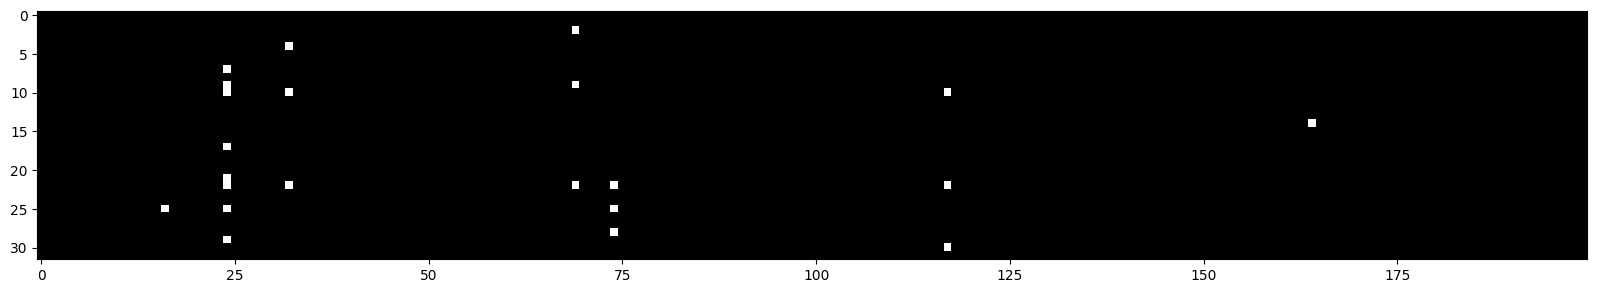

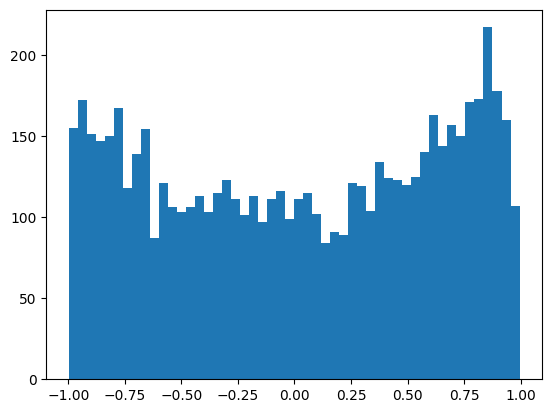

In [85]:
"""
after the initializations have been multiplied with smaller values, we get a better distributed values and
more active neurons, and the values of the hidden layer are spread less wide.
"""
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest');
plt.show()

plt.hist(h.view(-1).tolist(), bins=50);


In [ ]:
"""
In above examples the initialization was done with 'random' coefficients, testing which values produce
nicer distributions and more active functions. There are ways to actually calculate these values:
"""

tensor(0.0050) tensor(1.0126)
tensor(0.0014) tensor(1.0158)


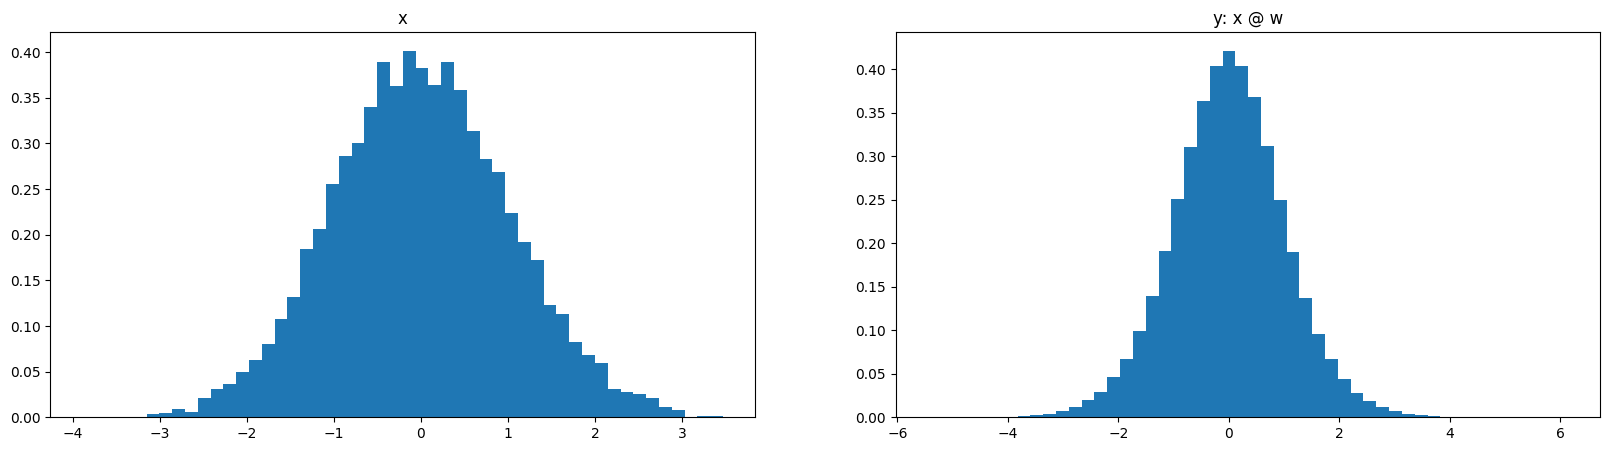

In [100]:
x = torch.randn(1000,10)
w = torch.randn(10, 200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.title('x')
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)
plt.title('y: x @ w')
plt.show()

In [ ]:
"""
in the above example, we can see that x @ w widens the standard deviation, i.e. it spreads the histogram
wider and the gaussian distribution is expanding from ~1.0 to ~3.2. We want a unit gaussian distribution
throughout the network. By multiplying the values of w, we can expand it more or make it less wide, and
have uniform standard deviation.

The correct way to get a uniform standard deviation is by dividing the weights values by the square root
of the fan_in value (fan_in, xx; number of input elements). And more precisely with Kaimin et. al, it's
gain / sqrt(fan_in) in this case, where gain is 5/3 for tanh function:

(5/3) / 30**0.5 ~=0.304..
"""

In [ ]:
"""
Batch normalization: https://arxiv.org/abs/1502.03167

Batch normalization happens in the pre-activation, where the batches are normalized before the
non-linear function:

(hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True)

above is the equation for standardizing activations to have batch mean 0 and batch standard deviation 1.
This does not mean the activations become normally distributed, it only fixes their location and scale
for that batch.

To avoid forcing the pre-activations to remain in this fixed standardized form, batch normalization
adds learnable scale and shift parameters. These allow the network to adapt the normalized activations
during training:

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

At initialization, these make batch normalization behave like plain standardization. During training,
they are updated by backpropagation so the network can learn the most useful scaling and shifting.
"""

In [ ]:
"""
During training, batch normalization introduces jitter because each mini-batch is normalized 
using its own mean and standard deviation. Since these batch statistics vary from batch to batch, 
the normalized activations also vary slightly, which adds noise to training. This noise can be 
somewhat useful as a regularizing effect. After training, we do not want that randomness 
anymore, so we calibrate batch norm by running the full training set through the network and 
measuring stable mean and standard deviation values to use during inference.

Also, after using batch normalization and bnbias, the b1 can be left out, since it's subtracted
in the normalization anyway. This can be done to all the layers where bnbias is present. meaning:

hnorm = ((xW + b1) - mean(xW + b1)) / std(xW + b1)

Because b1 is the same constant added to every example in the batch:
mean(xW + b1) = mean(xW) + b1

So numerator becomes:
(xW + b1) - (mean(xW) + b1) = xW - mean(xW)
and b1 cancels out completely


Batch normalization is usually used after a layer that includes multiplication.
"""